In [20]:
import pandas as pd

modules = pd.read_csv("louvain_modules.csv")

print(modules.head())
print("Nombre de modules:", modules["Module"].nunique())

   Gene  Module
0  6280       0
1  6279       0
2    60       0
3  6283       0
4  6282       1
Nombre de modules: 22


In [21]:
module_sizes = modules["Module"].value_counts()

print(module_sizes.head(10))

Module
1     253
12    138
6     123
0     101
5      87
3      77
9      25
8      25
2      20
15     16
Name: count, dtype: int64


In [22]:
hubs = pd.read_csv("hub_genes.csv")

print(hubs.head(20))

      Gene  DegreeCentrality
0   115727          0.250552
1     7408          0.249448
2    54458          0.247241
3     7454          0.247241
4     4688          0.241722
5   126364          0.237307
6   440926          0.235099
7    79143          0.232892
8     2783          0.231788
9     6386          0.231788
10    3020          0.231788
11    7879          0.229581
12  116985          0.228477
13  144423          0.227373
14    8125          0.227373
15    9260          0.226269
16     728          0.225166
17    8301          0.225166
18    3059          0.225166
19    8650          0.225166


In [23]:
merged = hubs.merge(modules, on="Gene")

print(merged.head())

     Gene  DegreeCentrality  Module
0  115727          0.250552       1
1    7408          0.249448       1
2   54458          0.247241       1
3    7454          0.247241       1
4    4688          0.241722       1


In [24]:
top_module = module_sizes.index[0]

important_genes = modules[modules["Module"] == top_module]

print(important_genes.head())


    Gene  Module
4   6282       1
5   9535       1
6   6888       1
10  6688       1
11  3055       1


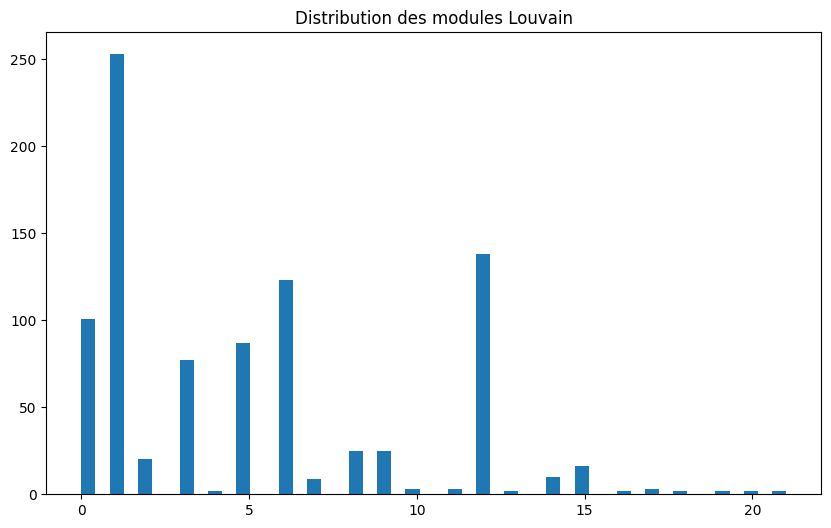

In [25]:
import matplotlib.pyplot as plt

colors = modules["Module"]

plt.figure(figsize=(10,6))
plt.hist(colors, bins=50)
plt.title("Distribution des modules Louvain")
plt.show()

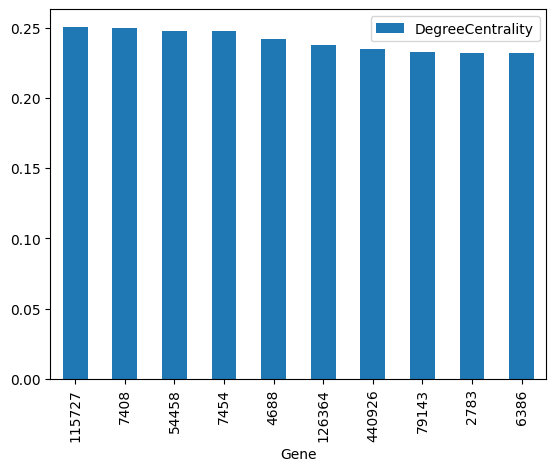

In [26]:
hubs.head(10).plot(
    x="Gene",
    y="DegreeCentrality",
    kind="bar"
)
plt.show()

In [27]:
import pandas as pd

annot = pd.read_csv(
    "Human.GRCh38.p13.annot.tsv",
    sep="\t"
)

print(annot.columns)
print(annot.head())

Index(['GeneID', 'Symbol', 'Description', 'Synonyms', 'GeneType',
       'EnsemblGeneID', 'Status', 'ChrAcc', 'ChrStart', 'ChrStop',
       'Orientation', 'Length', 'GOFunctionID', 'GOProcessID', 'GOComponentID',
       'GOFunction', 'GOProcess', 'GOComponent'],
      dtype='object')
      GeneID       Symbol                                 Description  \
0  100287102      DDX11L1  DEAD/H-box helicase 11 like 1 (pseudogene)   
1     653635       WASH7P           WASP family homolog 7, pseudogene   
2  102466751    MIR6859-1                             microRNA 6859-1   
3  107985730  MIR1302-2HG                         MIR1302-2 host gene   
4  100302278    MIR1302-2                             microRNA 1302-2   

                    Synonyms GeneType    EnsemblGeneID  Status        ChrAcc  \
0                        NaN   pseudo  ENSG00000290825  active  NC_000001.11   
1              FAM39F|WASH5P   pseudo              NaN  active  NC_000001.11   
2             hsa-mir-6859-1    ncRN

C:\Users\DELL\AppData\Local\Temp\ipykernel_11448\332096479.py:3: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  annot = pd.read_csv(


In [28]:
import pandas as pd

# Annotation
annot = pd.read_csv(
    "Human.GRCh38.p13.annot.tsv",
    sep="\t"
)

# Hubs
hubs = pd.read_csv("hub_genes.csv")

# Important : mêmes types
annot["GeneID"] = annot["GeneID"].astype(str)
hubs["Gene"] = hubs["Gene"].astype(str)

# Mapping
mapping = dict(zip(annot["GeneID"], annot["Symbol"]))

# Ajout symbole
hubs["Symbol"] = hubs["Gene"].map(mapping)

# Sauvegarde
hubs.to_csv(
    "hub_genes_symbols.csv",
    index=False
)

print(hubs.head(20))

      Gene  DegreeCentrality   Symbol
0   115727          0.250552  RASGRP4
1     7408          0.249448     VASP
2    54458          0.247241    PRR13
3     7454          0.247241      WAS
4     4688          0.241722     NCF2
5   126364          0.237307   LRRC25
6   440926          0.235099     H3P6
7    79143          0.232892   MBOAT7
8     2783          0.231788     GNB2
9     6386          0.231788    SDCBP
10    3020          0.231788    H3-3A
11    7879          0.229581    RAB7A
12  116985          0.228477    ARAP1
13  144423          0.227373   GLT1D1
14    8125          0.227373   ANP32A
15    9260          0.226269   PDLIM7
16     728          0.225166    C5AR1
17    8301          0.225166   PICALM
18    3059          0.225166    HCLS1
19    8650          0.225166     NUMB


C:\Users\DELL\AppData\Local\Temp\ipykernel_11448\3021763770.py:4: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  annot = pd.read_csv(


In [29]:
modules = pd.read_csv("louvain_modules.csv")

modules["Gene"] = modules["Gene"].astype(str)

modules["Symbol"] = modules["Gene"].map(mapping)

modules.to_csv(
    "louvain_modules_symbols.csv",
    index=False
)

print(modules.head())

   Gene  Module   Symbol
0  6280       0   S100A9
1  6279       0   S100A8
2    60       0     ACTB
3  6283       0  S100A12
4  6282       1  S100A11


In [30]:
components = pd.read_csv("connected_components.csv")

components["Gene"] = components["Gene"].astype(str)

components["Symbol"] = components["Gene"].map(mapping)

components.to_csv(
    "connected_components_symbols.csv",
    index=False
)

In [31]:
network = pd.read_csv("coexpression_network.csv")

network["Gene1"] = network["Gene1"].astype(str)
network["Gene2"] = network["Gene2"].astype(str)

network["Gene1_Symbol"] = network["Gene1"].map(mapping)
network["Gene2_Symbol"] = network["Gene2"].map(mapping)

network.to_csv(
    "coexpression_network_symbols.csv",
    index=False
)

In [32]:
hubs = pd.read_csv("hub_genes_symbols.csv")

print(hubs[["Gene","Symbol","DegreeCentrality"]].head(20))

      Gene   Symbol  DegreeCentrality
0   115727  RASGRP4          0.250552
1     7408     VASP          0.249448
2    54458    PRR13          0.247241
3     7454      WAS          0.247241
4     4688     NCF2          0.241722
5   126364   LRRC25          0.237307
6   440926     H3P6          0.235099
7    79143   MBOAT7          0.232892
8     2783     GNB2          0.231788
9     6386    SDCBP          0.231788
10    3020    H3-3A          0.231788
11    7879    RAB7A          0.229581
12  116985    ARAP1          0.228477
13  144423   GLT1D1          0.227373
14    8125   ANP32A          0.227373
15    9260   PDLIM7          0.226269
16     728    C5AR1          0.225166
17    8301   PICALM          0.225166
18    3059    HCLS1          0.225166
19    8650     NUMB          0.225166


In [33]:
import pandas as pd

modules = pd.read_csv("louvain_modules.csv")

sizes = modules["Module"].value_counts()

print(sizes.head(10))

Module
1     253
12    138
6     123
0     101
5      87
3      77
9      25
8      25
2      20
15     16
Name: count, dtype: int64


Nodes: 20
Edges: 137


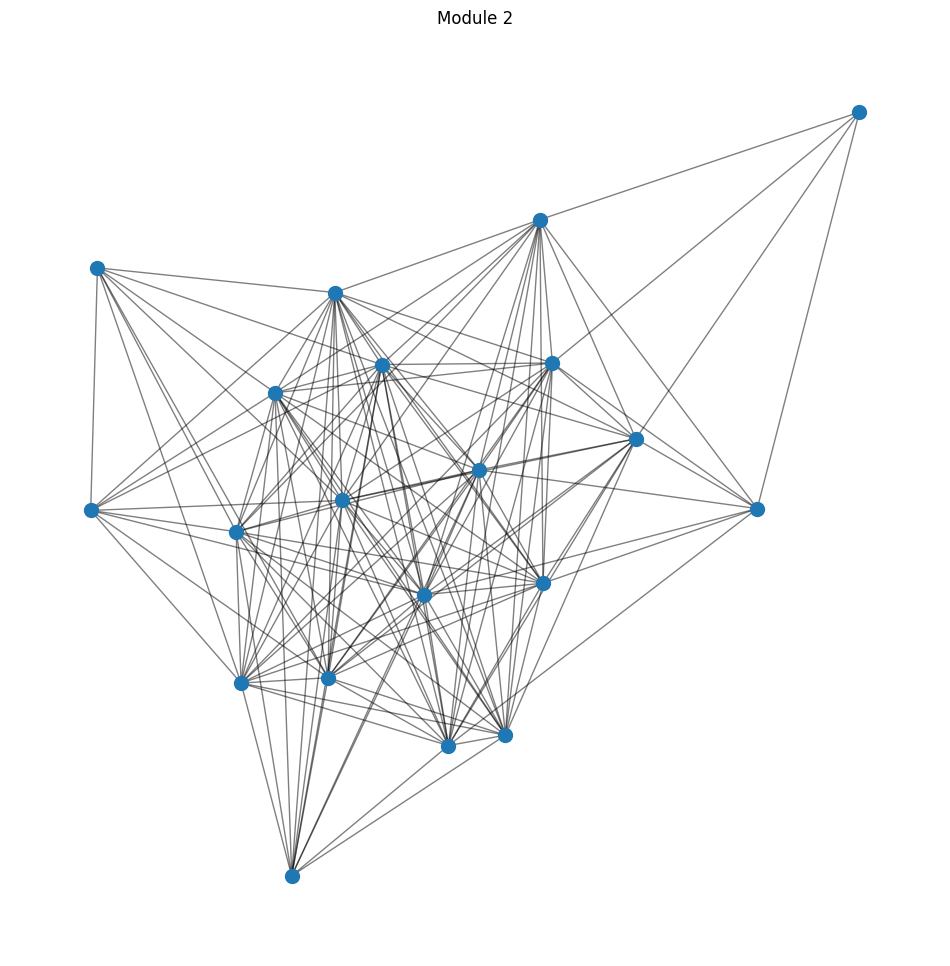

In [34]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Réseau
edges = pd.read_csv("coexpression_network.csv")

# Modules
modules = pd.read_csv("louvain_modules.csv")

# Construire le graphe complet
G = nx.from_pandas_edgelist(
    edges,
    source="Gene1",
    target="Gene2",
    edge_attr="Correlation"
)

# Choisir un module
module_id = 2

genes_module = modules[
    modules["Module"] == module_id
]["Gene"].tolist()

# Sous-graphe
subG = G.subgraph(genes_module)

print("Nodes:", subG.number_of_nodes())
print("Edges:", subG.number_of_edges())

plt.figure(figsize=(12,12))

pos = nx.spring_layout(
    subG,
    k=0.3,
    seed=42
)

nx.draw_networkx_nodes(
    subG,
    pos,
    node_size=100
)

nx.draw_networkx_edges(
    subG,
    pos,
    alpha=0.5
)

plt.title(f"Module {module_id}")
plt.axis("off")
plt.show()